In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [21]:
data = pd.read_csv("archive/data.csv")

In [22]:
data.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaN,2026-03-12 20:06:27+00:00,NaN,1,2200,...,POINT(-89.9711 35.1174),172697,-92.088678,34.127955,Memphis TN,-89.9711,35.1174,False,Bella Two-Tone Full-Zip Hooded Sweatshirt,Just received the Bella Two-Tone Full-Zip Hood...
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaN,2026-03-13 23:10:02+00:00,NaN,2,21920,...,POINT(-95.3698 29.7604),167157,-119.645815,36.534992,Houston TX,-95.3698,29.7604,False,Calvin Klein Sportswear Men's Broken Micro Che...,I really liked this Calvin Klein Sportswear Me...
2,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaN,2026-03-13 23:10:02+00:00,NaN,2,20031,...,POINT(-75.1667 39.95),167158,-119.645815,36.534992,Philadelphia PA,-75.1667,39.9500,False,FactoryExtreme Neptune Men's Black Biker Leath...,Nice FactoryExtreme Neptune Men's Black Biker ...
3,99949,79993,Complete,F,2026-03-11 00:39:44.268552+00:00,NaN,2026-03-13 17:24:44.268552+00:00,2026-03-16 01:00:44.268552+00:00,1,15500,...,POINT(-87.6847 41.8369),145310,116.501997,39.836316,Chicago IL,-87.6847,41.8369,False,HUE Women's 3-Pack Hidden Cotton Liner,Nice HUE Women's 3-Pack Hidden Cotton Liner. W...
4,92967,74352,Shipped,M,2026-03-11 00:39:29.765939+00:00,NaN,2026-03-12 11:30:29.765939+00:00,NaN,1,18572,...,POINT(-118.25 34.05),135249,2.455500,48.985509,Los Angeles CA,-118.2500,34.0500,False,Zorrel - Insect Shield Apparel Long Sleeve Tee...,Good value for money. The Zorrel - Insect Shie...


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545778 entries, 0 to 545777
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        545778 non-null  int64  
 1   user_id                         545778 non-null  int64  
 2   status                          545778 non-null  object 
 3   gender                          545778 non-null  object 
 4   created_at                      545778 non-null  object 
 5   returned_at                     54174 non-null   object 
 6   shipped_at                      354054 non-null  object 
 7   delivered_at                    190125 non-null  object 
 8   num_of_item                     545778 non-null  int64  
 9   product_id                      545778 non-null  int64  
 10  inventory_item_id               545778 non-null  int64  
 11  sale_price                      545778 non-null  float64
 12  id              

In [24]:
data.shape

(545778, 49)

In [25]:
duplicate_columns = []
columns = data.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col_i = columns[i]
        col_j = columns[j]
        if data[col_i].equals(data[col_j]):
            duplicate_columns.append(col_j)

duplicate_columns = list(dict.fromkeys(duplicate_columns))

data = data.drop(columns=duplicate_columns)

print(f"Удалены одинаковые столбцы: {duplicate_columns}")
print(f"Текущий размер data: {data.shape}")

Удалены одинаковые столбцы: ['id', 'retail_price', 'product_retail_price', 'product_category', 'product_brand', 'product_department', 'product_sku', 'product_distribution_center_id', 'product_name_clean']
Текущий размер data: (545778, 40)


In [26]:
duplicates_count = data.duplicated().sum()
rows_before = len(data)

data = data.drop_duplicates().reset_index(drop=True)

rows_after = len(data)
removed_rows = rows_before - rows_after

print(f"Полных дубликатов найдено: {duplicates_count}")
print(f"Удалено строк: {removed_rows}")
print(f"Размер после очистки: {rows_after}")


Полных дубликатов найдено: 363852
Удалено строк: 363852
Размер после очистки: 181926


In [27]:
# fe = []
# for col in data.columns:
#     if (len(data[col].unique()) == data.shape[0]): fe.append(col)
# data = data.drop(columns=fe)
# print(len(fe))

In [28]:
data.shape

(181926, 40)

In [29]:
data["brand"] = data["brand"].fillna("no brand")
data["product_name"] = data["product_name"].fillna("no name")

In [30]:
data.isnull().sum()

order_id                         0
user_id                          0
status                           0
gender                           0
created_at                       0
returned_at                 163868
shipped_at                   63908
delivered_at                118551
num_of_item                      0
product_id                       0
inventory_item_id                0
sale_price                       0
first_name                       0
last_name                        0
email                            0
age                              0
state                            0
street_address                   0
postal_code                      0
city                          1818
country                          0
traffic_source                   0
user_geom                        0
cost                             0
category                         0
brand                            0
department                       0
sku                              0
distribution_center_

In [31]:
data = data.drop(columns=["sold_at"])

In [32]:
city_mode = data["city"].mode(dropna=True)
data["city"] = data["city"].fillna(city_mode.iloc[0] if not city_mode.empty else np.nan)

data.isna().sum().sort_values(ascending=False)

returned_at                 163868
delivered_at                118551
shipped_at                   63908
order_id                         0
distribution_center_geom         0
cost                             0
category                         0
brand                            0
department                       0
sku                              0
distribution_center_id           0
product_name                     0
delivery_longitude               0
order_item_id                    0
traffic_source                   0
delivery_latitude                0
warehouse_name                   0
warehouse_longitude              0
warehouse_latitude               0
is_loyal                         0
user_geom                        0
city                             0
country                          0
sale_price                       0
status                           0
gender                           0
created_at                       0
num_of_item                      0
product_id          

In [33]:
data.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'first_name', 'last_name', 'email',
       'age', 'state', 'street_address', 'postal_code', 'city', 'country',
       'traffic_source', 'user_geom', 'cost', 'category', 'brand',
       'department', 'sku', 'distribution_center_id', 'product_name',
       'distribution_center_geom', 'order_item_id', 'delivery_longitude',
       'delivery_latitude', 'warehouse_name', 'warehouse_longitude',
       'warehouse_latitude', 'is_loyal', 'customer_review'],
      dtype='object')

In [34]:
sales_data = data.copy()

sales_data = sales_data.loc[sales_data["status"] != "Cancelled"].copy()
sales_data["order_day"] = sales_data["created_at"].dt.tz_convert(None).dt.floor("D")

daily_sales = (
    sales_data.groupby("order_day")
    .agg(
        items=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("sale_price", "sum"),
    )
    .sort_index()
)

daily_sales = daily_sales.reindex(
    pd.date_range(daily_sales.index.min(), daily_sales.index.max(), freq="D"),
    fill_value=0,
)

daily_sales.index.name = "date"

print(f"{daily_sales.index.min().date()} - {daily_sales.index.max().date()}")
print(f" days {len(daily_sales)}")

daily_sales.sample(10)

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
monthly_sales = (
    daily_sales.resample("MS")
    .agg(
        items=("items", "sum"),
        orders=("orders", "sum"),
        revenue=("revenue", "sum"),
    )
)


print(f"mounth: {len(monthly_sales)}")

monthly_sales


mounth: 87


,items,orders,revenue
date,,,
2019-01-01,19,10,1288.999993
2019-02-01,30,20,2777.360008
2019-03-01,44,28,2719.240001
2019-04-01,73,47,3864.990003
2019-05-01,88,56,5568.520005
...,...,...,...
2025-11-01,5373,3684,315108.510362
2025-12-01,5996,4173,353069.120448
2026-01-01,6696,4704,401981.130435


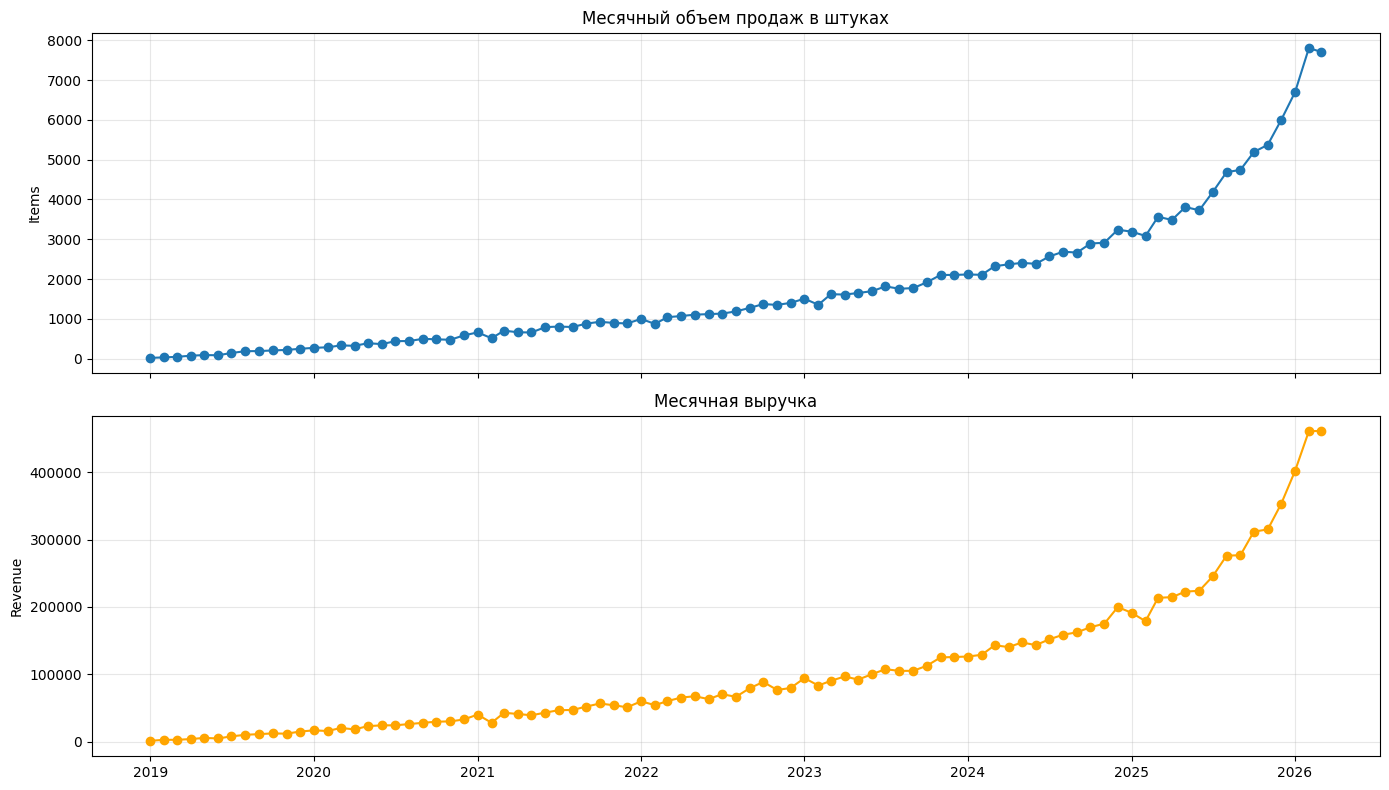

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_sales.index, monthly_sales["items"], marker="o")
axes[0].set_title("Месячный объем продаж в штуках")
axes[0].set_ylabel("Items")
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_sales.index, monthly_sales["revenue"], marker="o", color="orange")
axes[1].set_title("Месячная выручка")
axes[1].set_ylabel("Revenue")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


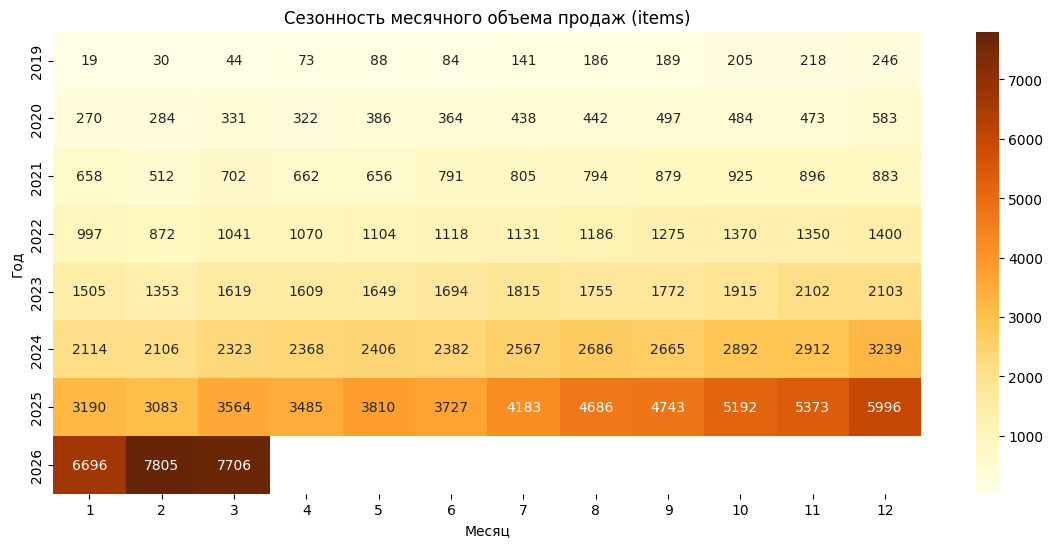

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2019,19.0,30.0,44.0,73.0,88.0,84.0,141.0,186.0,189.0,205.0,218.0,246.0
2020,270.0,284.0,331.0,322.0,386.0,364.0,438.0,442.0,497.0,484.0,473.0,583.0
2021,658.0,512.0,702.0,662.0,656.0,791.0,805.0,794.0,879.0,925.0,896.0,883.0
2022,997.0,872.0,1041.0,1070.0,1104.0,1118.0,1131.0,1186.0,1275.0,1370.0,1350.0,1400.0
2023,1505.0,1353.0,1619.0,1609.0,1649.0,1694.0,1815.0,1755.0,1772.0,1915.0,2102.0,2103.0
2024,2114.0,2106.0,2323.0,2368.0,2406.0,2382.0,2567.0,2686.0,2665.0,2892.0,2912.0,3239.0
2025,3190.0,3083.0,3564.0,3485.0,3810.0,3727.0,4183.0,4686.0,4743.0,5192.0,5373.0,5996.0
2026,6696.0,7805.0,7706.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
seasonality_df = monthly_sales.copy()
seasonality_df["year"] = seasonality_df.index.year
seasonality_df["month"] = seasonality_df.index.month

seasonality_table = seasonality_df.pivot_table(
    index="year",
    columns="month",
    values="items",
    aggfunc="sum",
)

plt.figure(figsize=(14, 6))
sns.heatmap(seasonality_table, annot=True, fmt=".0f", cmap="YlOrBr")
plt.title("Сезонность месячного объема продаж (items)")
plt.xlabel("Месяц")
plt.ylabel("Год")
plt.show()

seasonality_table


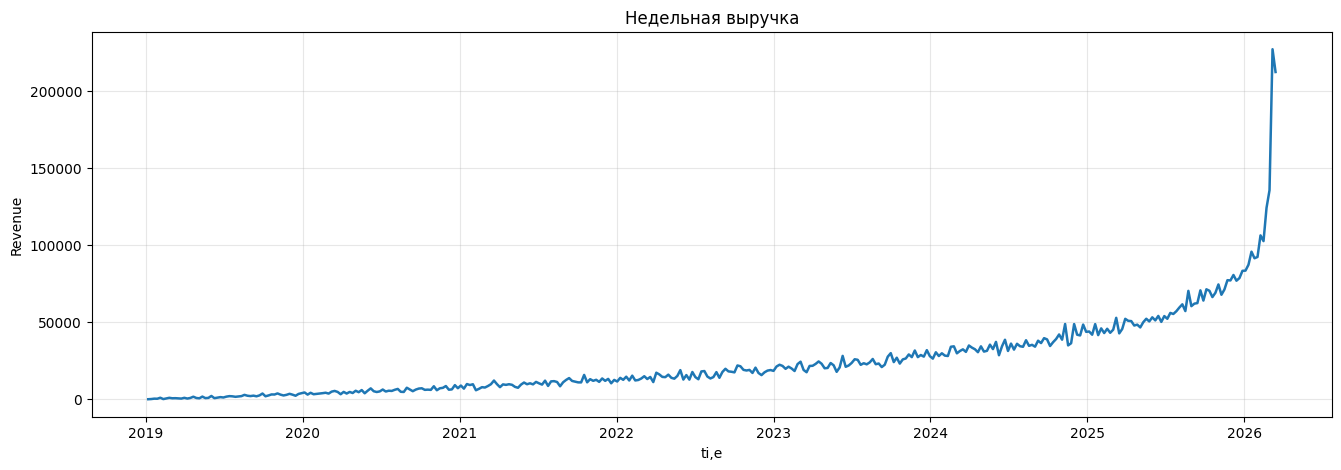

,items,orders,revenue
date,,,
2026-02-15,1773,1211,102580.020075
2026-02-22,2035,1375,124145.240010
2026-03-01,2300,1531,135620.240081
2026-03-08,3776,2613,227063.540124
2026-03-15,3573,2444,212283.740271


In [ ]:
weekly_sales = (
    daily_sales.resample("W")
    .agg(
        items=("items", "sum"),
        orders=("orders", "sum"),
        revenue=("revenue", "sum"),
    )
)

plt.figure(figsize=(16, 5))
plt.plot(weekly_sales.index, weekly_sales["revenue"], linewidth=1.8)
plt.title("Недельная выручка")
plt.xlabel("ti,e")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

weekly_sales.tail()


In [ ]:
monthly_sales = (
    daily_sales.resample("MS") #"W"
    .agg(
        items=("items", "sum"),
        orders=("orders", "sum"),
        revenue=("revenue", "sum"),
    )
)

print(f"Горизонт недельного ряда: {weekly_sales.index.min().date()} - {weekly_sales.index.max().date()}")
print(f"Количество недель: {len(weekly_sales)}")

weekly_sales.tail()


Горизонт недельного ряда: 2019-01-06 - 2026-03-15
Количество недель: 376


,items,orders,revenue
date,,,
2026-02-15,1773,1211,102580.020075
2026-02-22,2035,1375,124145.240010
2026-03-01,2300,1531,135620.240081
2026-03-08,3776,2613,227063.540124
2026-03-15,3573,2444,212283.740271


In [ ]:
target = monthly_sales["items"].copy()

model_data = pd.DataFrame({"target": target})

model_data["lag_1"] = model_data["target"].shift(1)
model_data["lag_2"] = model_data["target"].shift(2)
model_data["lag_3"] = model_data["target"].shift(3)
model_data["lag_6"] = model_data["target"].shift(6)

model_data["rolling_mean_3"] = model_data["target"].shift(1).rolling(3).mean()
model_data["rolling_mean_6"] = model_data["target"].shift(1).rolling(6).mean()

model_data["month"] = model_data.index.month
model_data["quarter"] = model_data.index.quarter
model_data["time_idx"] = np.arange(len(model_data))

model_data = model_data.dropna()

model_data.sample(5)


,target,lag_1,lag_2,lag_3,lag_6,rolling_mean_3,rolling_mean_6,month,quarter,time_idx
date,,,,,,,,,,
2020-08-01,442,438.0,364.0,386.0,284.0,396.000000,354.166667,8,3,19
2024-07-01,2567,2382.0,2406.0,2368.0,2114.0,2385.333333,2283.166667,7,3,66
2019-08-01,186,141.0,84.0,88.0,30.0,104.333333,76.666667,8,3,7
2023-05-01,1649,1609.0,1619.0,1353.0,1350.0,1527.000000,1472.666667,5,2,52
2020-07-01,438,364.0,386.0,322.0,270.0,357.333333,326.166667,7,3,18


In [ ]:
model_data.columns

Index(['target', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_mean_3',
       'rolling_mean_6', 'month', 'quarter', 'time_idx'],
      dtype='object')

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [ ]:
X = model_data.drop(columns="target")
y = model_data["target"]

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

baseline_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    baseline_pred = X_test["lag_1"]
    fold_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_scores.append(fold_mae)

    print(f"Fold {fold}: MAE = {fold_mae:.2f}")


Fold 1: MAE = 69.08
Fold 2: MAE = 63.08
Fold 3: MAE = 89.08
Fold 4: MAE = 106.69
Fold 5: MAE = 395.77


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
linear_oof = pd.Series(index=y.index, dtype=float)
tree_oof = pd.Series(index=y.index, dtype=float)
forest_oof = pd.Series(index=y.index, dtype=float)

In [ ]:
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    linear_oof.iloc[test_idx] = linear_model.predict(X_test)

    tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
    tree_model.fit(X_train, y_train)
    tree_oof.iloc[test_idx] = tree_model.predict(X_test)

    forest_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )
    forest_model.fit(X_train, y_train)
    forest_oof.iloc[test_idx] = forest_model.predict(X_test)

comparison_models = pd.DataFrame({
    "actual": y,
    "linear_pred": linear_oof,
    "tree_pred": tree_oof,
    "forest_pred": forest_oof,
})


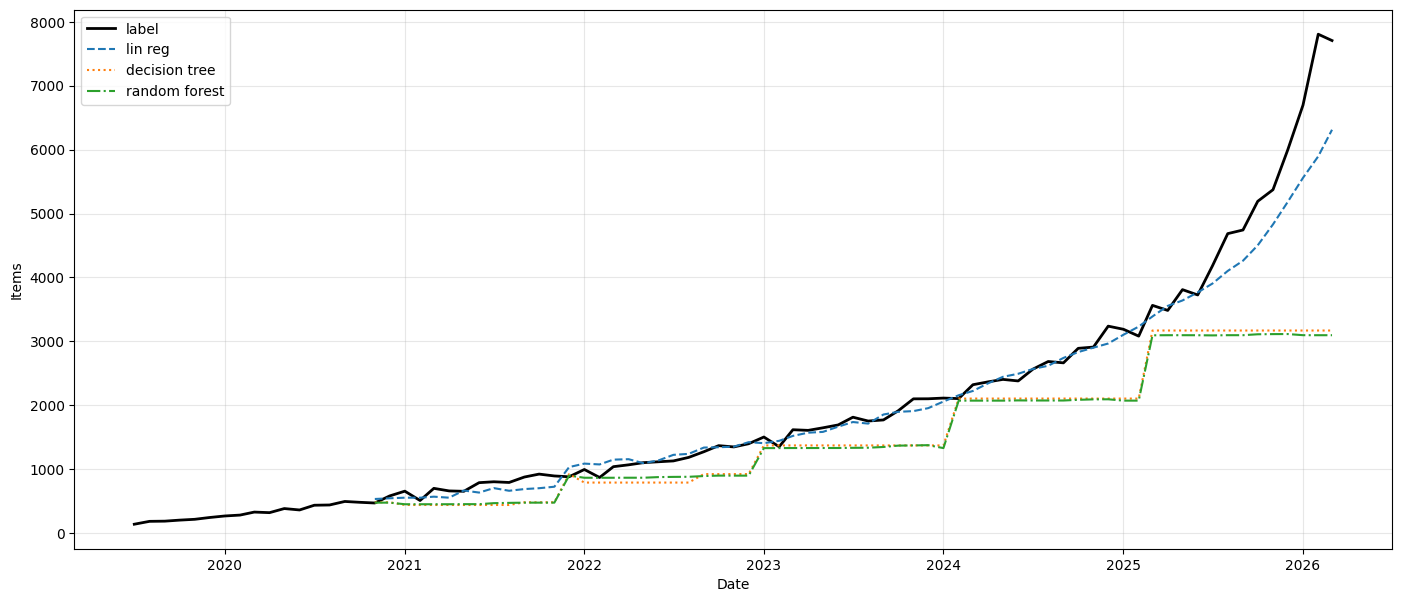

In [ ]:
plt.figure(figsize=(17, 7))
plt.plot(comparison_models.index, comparison_models["actual"], label="label", linewidth=2, color="black")
plt.plot(comparison_models.index, comparison_models["linear_pred"], label="lin reg", linestyle="--")
plt.plot(comparison_models.index, comparison_models["tree_pred"], label="decision tree", linestyle=":")
plt.plot(comparison_models.index, comparison_models["forest_pred"], label="random forest", linestyle="-.")
plt.xlabel("Date")
plt.ylabel("Items")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plain_scores = []
scaled_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    plain_model = LinearRegression()
    plain_model.fit(X_train, y_train)
    plain_pred = plain_model.predict(X_test)
    plain_mae = mean_absolute_error(y_test, plain_pred)
    plain_scores.append(plain_mae)

    scaled_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    scaled_model.fit(X_train, y_train)
    scaled_pred = scaled_model.predict(X_test)
    scaled_mae = mean_absolute_error(y_test, scaled_pred)
    scaled_scores.append(scaled_mae)

    print(
        f"Fold {fold}: "
        f"Linear MAE = {plain_mae:.2f}, "
        f"Scaled Linear MAE = {scaled_mae:.2f}"
    )

Fold 1: Linear MAE = 111.88, Scaled Linear MAE = 111.88
Fold 2: Linear MAE = 72.65, Scaled Linear MAE = 72.65
Fold 3: Linear MAE = 78.64, Scaled Linear MAE = 78.64
Fold 4: Linear MAE = 80.30, Scaled Linear MAE = 80.30
Fold 5: Linear MAE = 637.03, Scaled Linear MAE = 637.03


In [ ]:
print(f"mean MAE linReg: {np.mean(plain_scores):.2f}")
print(f"mean MAE linReg Scaled: {np.mean(scaled_scores):.2f}")

mean MAE linReg: 196.10
mean MAE linReg Scaled: 196.10


In [ ]:
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    linear_oof.iloc[test_idx] = linear_model.predict(X_test)

linear_comparison = pd.DataFrame({
    "actual": y,
    "linear_pred": linear_oof,
})

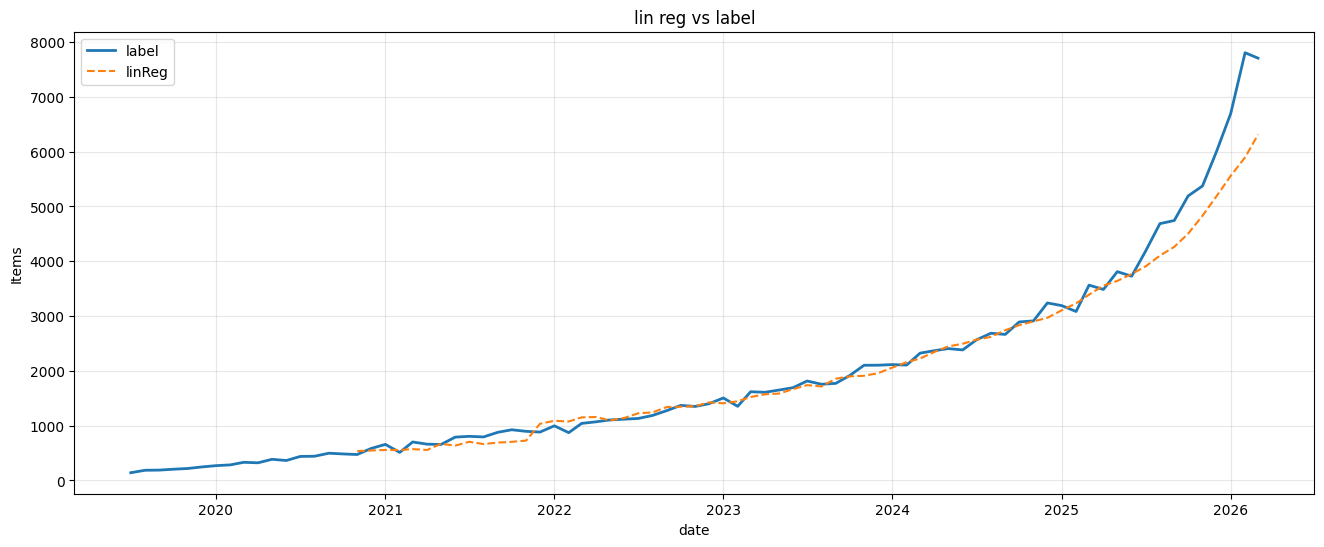

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(linear_comparison.index, linear_comparison["actual"], label="label", linewidth=2)
plt.plot(linear_comparison.index, linear_comparison["linear_pred"], label="linReg", linestyle="--")
plt.title("lin reg vs label")
plt.ylabel("Items")
plt.xlabel("date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
X.columns

Index(['lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_mean_3', 'rolling_mean_6',
       'month', 'quarter', 'time_idx'],
      dtype='object')

In [ ]:
interpretable_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

interpretable_model.fit(X, y)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": interpretable_model.named_steps["model"].coef_,
}).sort_values("coefficient", ascending=False)


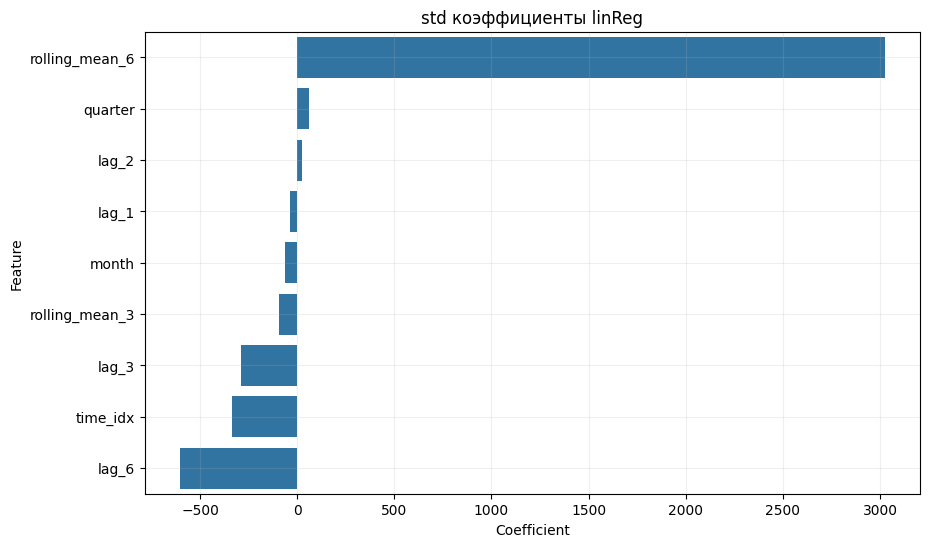

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x="coefficient", y="feature")
plt.title("std коэффициенты linReg")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
coef_df

,feature,coefficient
5,rolling_mean_6,3023.433199
7,quarter,62.319509
1,lag_2,26.896677
0,lag_1,-38.948590
6,month,-59.978766
4,rolling_mean_3,-94.402901
2,lag_3,-288.656294
8,time_idx,-336.588696
3,lag_6,-602.758032


основной драйвер прогноза — недавний средний уровень продаж, особенно rolling_mean_6;
дополнительные лаги корректируют этот базовый уровень;
календарные признаки играют вторичную роль;
модель в первую очередь ловит инерцию ряда, а не сложную сезонность.

1. Линейная регрессия в основном опирается на сглаженный исторический уровень продаж за предыдущие периоды.
2. Наиболее значимым признаком оказался rolling_mean_6, что говорит о высокой инерционности ряда.
3. Отдельные лаговые признаки получили разнонаправленные коэффициенты из-за высокой корреляции между лагами и скользящими средними.
4. Календарные признаки оказывают меньшее влияние, чем историческая динамика продаж.
5. Модель отражает прежде всего тренд и инерцию спроса, что соответствует задаче планирования закупок.

In [ ]:
from sklearn.linear_model import Ridge

feature_cols_ridge = [
    "lag_1",
    "lag_6",
    "rolling_mean_6",
    "month",
    "time_idx",
]

X_ridge = model_data[feature_cols_ridge].copy()
y_ridge = model_data["target"].copy()


In [ ]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_ridge, y_ridge)

ridge_coef_df = pd.DataFrame({
    "feature": feature_cols_ridge,
    "coefficient": ridge_model.named_steps["model"].coef_,
}).sort_values("coefficient", ascending=False)

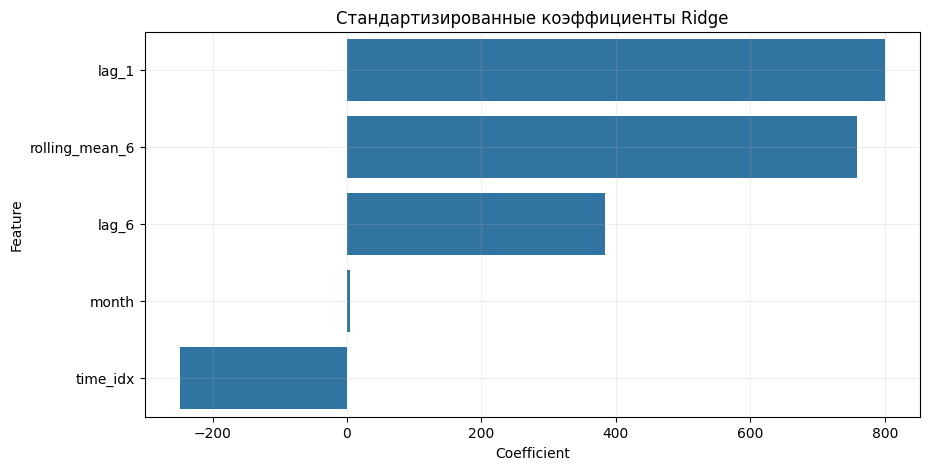

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ridge_coef_df, x="coefficient", y="feature")
plt.title("Стандартизированные коэффициенты Ridge")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
ridge_coef_df

,feature,coefficient
0,lag_1,799.779858
2,rolling_mean_6,758.830707
1,lag_6,383.227045
3,month,5.203315
4,time_idx,-248.427013


Интерпретация Ridge-модели показала, что ключевыми факторами прогноза объема продаж являются краткосрочная инерция спроса (lag_1), средний уровень продаж за последние 6 месяцев (rolling_mean_6) и продажи полугодовой давности (lag_6). Это указывает на высокую зависимость текущего объема продаж от собственной исторической динамики. Календарный фактор месяца оказывает минимальное влияние, следовательно, в данных выраженный тренд и инерция значимее сезонности.

In [ ]:
full_feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "month",
    "quarter",
    "time_idx",
]

ridge_feature_cols = [
    "lag_1",
    "lag_6",
    "rolling_mean_6",
    "month",
    "time_idx",
]

X_full = model_data[full_feature_cols].copy()
X_ridge = model_data[ridge_feature_cols].copy()
y = model_data["target"].copy()

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

linear_oof = pd.Series(index=y.index, dtype=float)
ridge_oof = pd.Series(index=y.index, dtype=float)

linear_scores = []
ridge_scores = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(y), start=1):
    X_full_train, X_full_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    X_ridge_train, X_ridge_test = X_ridge.iloc[train_idx], X_ridge.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    linear_model = LinearRegression()
    linear_model.fit(X_full_train, y_train)
    linear_pred = linear_model.predict(X_full_test)
    linear_oof.iloc[test_idx] = linear_pred
    linear_scores.append(mean_absolute_error(y_test, linear_pred))

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
    ridge_model.fit(X_ridge_train, y_train)
    ridge_pred = ridge_model.predict(X_ridge_test)
    ridge_oof.iloc[test_idx] = ridge_pred
    ridge_scores.append(mean_absolute_error(y_test, ridge_pred))

    print(
        f"Fold {fold}: "
        f"Linear MAE = {linear_scores[-1]:.2f}, "
        f"Ridge MAE = {ridge_scores[-1]:.2f}"
    )

print(f"\nСредний MAE LinearRegression: {np.mean(linear_scores):.2f}")
print(f"Средний MAE Ridge: {np.mean(ridge_scores):.2f}")

Fold 1: Linear MAE = 111.88, Ridge MAE = 60.37
Fold 2: Linear MAE = 72.65, Ridge MAE = 42.76
Fold 3: Linear MAE = 78.64, Ridge MAE = 108.86
Fold 4: Linear MAE = 80.30, Ridge MAE = 121.32
Fold 5: Linear MAE = 637.03, Ridge MAE = 699.34

Средний MAE LinearRegression: 196.10
Средний MAE Ridge: 206.53


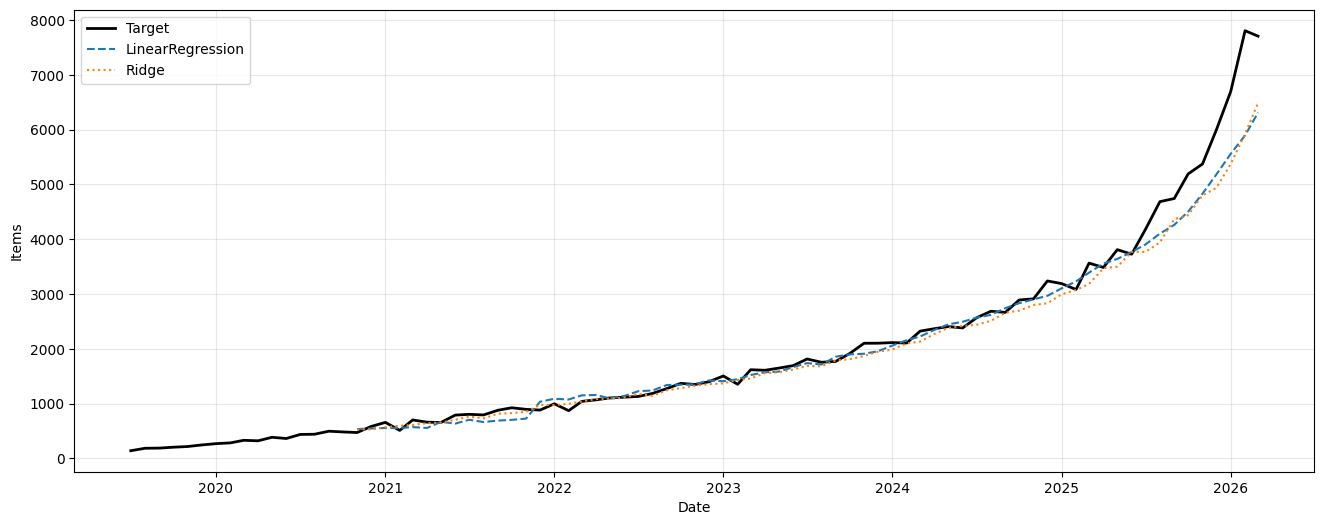

,target,linear_pred,ridge_pred
date,,,
2024-08-01,2686,2619.672290,2511.393409
2024-09-01,2665,2742.009374,2658.473550
2024-10-01,2892,2833.635940,2697.107971
2024-11-01,2912,2902.893924,2799.452985
2024-12-01,3239,2967.585602,2831.276058
2025-01-01,3190,3104.716013,2997.566824
2025-02-01,3083,3232.041801,3073.141715
2025-03-01,3564,3390.591765,3185.155824
2025-04-01,3485,3555.609458,3470.302059


In [ ]:
comparison_df = pd.DataFrame({
    "target": y,
    "linear_pred": linear_oof,
    "ridge_pred": ridge_oof,
})

plt.figure(figsize=(16, 6))
plt.plot(comparison_df.index, comparison_df["target"], label="Target", linewidth=2, color="black")
plt.plot(comparison_df.index, comparison_df["linear_pred"], label="LinearRegression", linestyle="--")
plt.plot(comparison_df.index, comparison_df["ridge_pred"], label="Ridge", linestyle=":")
plt.xlabel("Date")
plt.ylabel("Items")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

comparison_df.tail(20)

для прогноза были проверены несколько моделей;
по средней ошибке лучшей оказалась LinearRegression;
однако для интерпретации факторов использована Ridge, так как она устойчивее при высокой корреляции лаговых признаков;
обе модели показывают схожее качество и одинаково фиксируют общий восходящий тренд продаж.


In [ ]:
weekly_target = weekly_sales["items"].copy()

weekly_model_data = pd.DataFrame({"target": weekly_target})
weekly_model_data["lag_1"] = weekly_model_data["target"].shift(1)
weekly_model_data["lag_4"] = weekly_model_data["target"].shift(4)
weekly_model_data["lag_12"] = weekly_model_data["target"].shift(12)
weekly_model_data["rolling_mean_4"] = weekly_model_data["target"].shift(1).rolling(4).mean()
weekly_model_data["rolling_mean_12"] = weekly_model_data["target"].shift(1).rolling(12).mean()
weekly_model_data["month"] = weekly_model_data.index.month
weekly_model_data["quarter"] = weekly_model_data.index.quarter
weekly_model_data["time_idx"] = np.arange(len(weekly_model_data))

weekly_model_data = weekly_model_data.dropna()

weekly_model_data.sample(5)

,target,lag_1,lag_4,lag_12,rolling_mean_4,rolling_mean_12,month,quarter,time_idx
date,,,,,,,,,
2023-03-26,362,344.0,393.0,325.0,370.25,343.333333,3,1,220
2025-05-18,882,847.0,792.0,765.0,819.25,804.416667,5,2,332
2023-09-17,400,371.0,433.0,374.0,389.00,395.500000,9,3,245
2019-12-29,62,59.0,52.0,32.0,51.00,50.333333,12,4,51
2024-12-08,693,746.0,745.0,607.0,687.75,657.083333,12,4,309


In [ ]:
weekly_feature_cols = [
    "lag_1",
    "lag_4",
    "lag_12",
    "rolling_mean_4",
    "rolling_mean_12",
    "month",
    "quarter",
    "time_idx",
]

X_weekly = weekly_model_data[weekly_feature_cols].copy()
y_weekly = weekly_model_data["target"].copy()

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

weekly_ridge_oof = pd.Series(index=y_weekly.index, dtype=float)
weekly_ridge_scores = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_weekly), start=1):
    X_train, X_test = X_weekly.iloc[train_idx], X_weekly.iloc[test_idx]
    y_train, y_test = y_weekly.iloc[train_idx], y_weekly.iloc[test_idx]

    weekly_ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    weekly_ridge_model.fit(X_train, y_train)
    ridge_pred = weekly_ridge_model.predict(X_test)

    weekly_ridge_oof.iloc[test_idx] = ridge_pred
    weekly_ridge_scores.append(mean_absolute_error(y_test, ridge_pred))

    print(f"Fold {fold}: Ridge weekly MAE = {weekly_ridge_scores[-1]:.2f}")

print(f"\nСредний weekly MAE Ridge: {np.mean(weekly_ridge_scores):.2f}")

weekly_comparison_df = pd.DataFrame({
    "target": y_weekly,
    "ridge_pred": weekly_ridge_oof,
})

Fold 1: Ridge weekly MAE = 15.64
Fold 2: Ridge weekly MAE = 17.52
Fold 3: Ridge weekly MAE = 26.52
Fold 4: Ridge weekly MAE = 28.98
Fold 5: Ridge weekly MAE = 136.41

Средний weekly MAE Ridge: 45.01


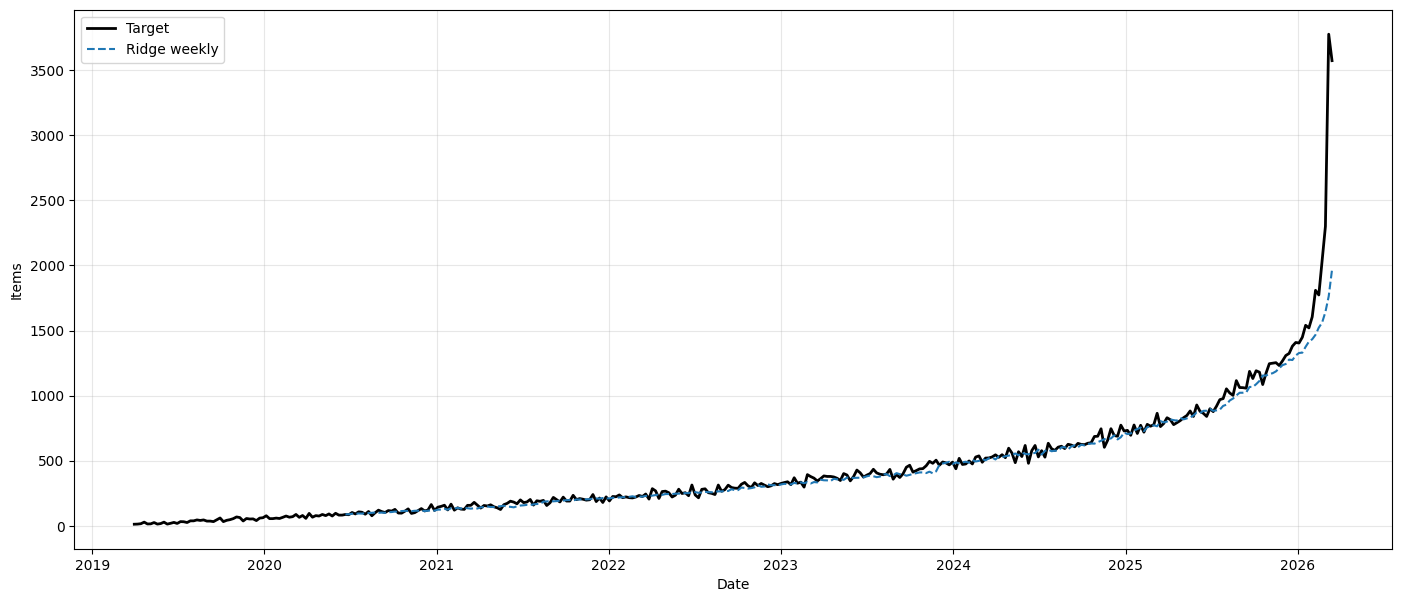

In [ ]:
plt.figure(figsize=(17, 7))
plt.plot(weekly_comparison_df.index, weekly_comparison_df["target"], label="Target", linewidth=2, color="black")
plt.plot(weekly_comparison_df.index, weekly_comparison_df["ridge_pred"], label="Ridge weekly", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Items")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
weekly_feature_cols = [
    "lag_1",
    "lag_4",
    "lag_12",
    "rolling_mean_4",
    "rolling_mean_12",
    "month",
    "quarter",
    "time_idx",
]

final_weekly_ridge_model = Ridge(alpha=1.0)
final_weekly_ridge_model.fit(X_weekly, y_weekly)

weekly_fitted_df = pd.DataFrame({
    "target": y_weekly,
    "ridge_fitted": final_weekly_ridge_model.predict(X_weekly),
}, index=X_weekly.index)

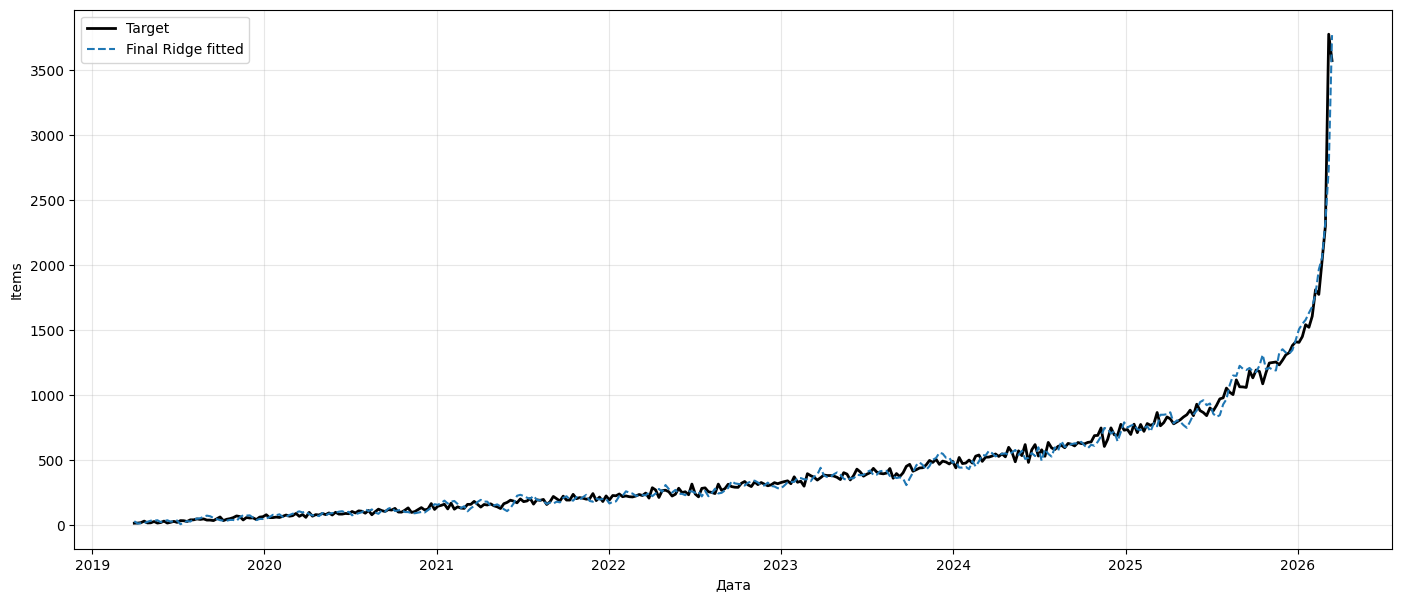

,target,ridge_fitted
date,,
2025-11-02,1245,1208.251397
2025-11-09,1249,1193.995004
2025-11-16,1253,1187.583144
2025-11-23,1231,1322.454053
2025-11-30,1267,1351.067903
2025-12-07,1308,1325.248651
2025-12-14,1324,1316.119396
2025-12-21,1380,1344.894585
2025-12-28,1408,1421.763145


In [ ]:
plt.figure(figsize=(17, 7))
plt.plot(weekly_fitted_df.index, weekly_fitted_df["target"], label="Target", linewidth=2, color="black")
plt.plot(weekly_fitted_df.index, weekly_fitted_df["ridge_fitted"], label="Final Ridge fitted", linestyle="--")
plt.xlabel("Дата")
plt.ylabel("Items")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

weekly_fitted_df.tail(20)

In [ ]:
def forecast_weekly_ridge(model, weekly_history, horizon=8):
    history = weekly_history.copy().astype(float)
    future_dates = pd.date_range(
        history.index.max() + pd.Timedelta(weeks=1),
        periods=horizon,
        freq="W",
    )

    forecasts = []

    for next_date in future_dates:
        next_features = pd.DataFrame(
            {
                "lag_1": [history.iloc[-1]],
                "lag_4": [history.iloc[-4]],
                "lag_12": [history.iloc[-12]],
                "rolling_mean_4": [history.iloc[-4:].mean()],
                "rolling_mean_12": [history.iloc[-12:].mean()],
                "month": [next_date.month],
                "quarter": [next_date.quarter],
                "time_idx": [len(history)],
            },
            index=[next_date],
        )

        next_pred = model.predict(next_features)[0]
        forecasts.append(next_pred)
        history.loc[next_date] = next_pred

    forecast_df = pd.DataFrame(
        {"forecast_items": forecasts},
        index=future_dates,
    )

    return forecast_df


In [ ]:
weekly_forecast = forecast_weekly_ridge(
    model=final_weekly_ridge_model,
    weekly_history=weekly_model_data["target"],
    horizon=8,
)

weekly_forecast.iloc[0]


forecast_items    4995.521697
Name: 2026-03-22 00:00:00, dtype: float64

In [ ]:
def preprocess_data(raw_data: pd.DataFrame) -> pd.DataFrame:
    data = raw_data.copy()

    duplicate_columns = [
        "id",
        "retail_price",
        "product_retail_price",
        "product_category",
        "product_brand",
        "product_department",
        "product_sku",
        "product_distribution_center_id",
        "product_name_clean",
    ]
    data = data.drop(columns=[c for c in duplicate_columns if c in data.columns], errors="ignore")

    data = data.drop_duplicates().reset_index(drop=True)

    unique_cols = [col for col in data.columns if data[col].nunique(dropna=False) == len(data)]
    data = data.drop(columns=unique_cols, errors="ignore")

    if "brand" in data.columns:
        data["brand"] = data["brand"].fillna("no brand")

    if "product_name" in data.columns:
        data["product_name"] = data["product_name"].fillna("no name")

    if "city" in data.columns:
        city_mode = data["city"].mode(dropna=True)
        if not city_mode.empty:
            data["city"] = data["city"].fillna(city_mode.iloc[0])

    if "sold_at" in data.columns:
        data = data.drop(columns=["sold_at"], errors="ignore")

    data["created_at"] = pd.to_datetime(
        data["created_at"],
        errors="coerce",
        utc=True,
        format="mixed",
    )

    data = data.dropna(subset=["created_at"])
    data = data.loc[data["status"] != "Cancelled"].copy()

    data["order_day"] = data["created_at"].dt.tz_convert(None).dt.floor("D")

    daily_sales = (
        data.groupby("order_day")
        .agg(
            items=("order_item_id", "count"),
            orders=("order_id", "nunique"),
            revenue=("sale_price", "sum"),
        )
        .sort_index()
    )

    daily_sales = daily_sales.reindex(
        pd.date_range(daily_sales.index.min(), daily_sales.index.max(), freq="D"),
        fill_value=0,
    )
    daily_sales.index.name = "date"

    weekly_sales = (
        daily_sales.resample("W")
        .agg(
            items=("items", "sum"),
            orders=("orders", "sum"),
            revenue=("revenue", "sum"),
        )
    )

    return weekly_sales


In [ ]:
def make_weekly_features(weekly_sales: pd.DataFrame) -> pd.DataFrame:
    weekly_target = weekly_sales["items"].astype(float)

    if len(weekly_target) < 12:
        raise ValueError("Для прогноза нужны минимум 12 недель истории.")

    next_date = weekly_target.index.max() + pd.Timedelta(weeks=1)

    features = pd.DataFrame(
        {
            "lag_1": [weekly_target.iloc[-1]],
            "lag_4": [weekly_target.iloc[-4]],
            "lag_12": [weekly_target.iloc[-12]],
            "rolling_mean_4": [weekly_target.iloc[-4:].mean()],
            "rolling_mean_12": [weekly_target.iloc[-12:].mean()],
            "month": [next_date.month],
            "quarter": [next_date.quarter],
            "time_idx": [len(weekly_target)],
        },
        index=[next_date],
    )

    return features

In [ ]:
def predict_next_week(raw_data: pd.DataFrame, model) -> pd.DataFrame:
    weekly_sales = preprocess_data(raw_data)
    next_week_features = make_weekly_features(weekly_sales)
    next_prediction = model.predict(next_week_features)[0]

    result = pd.DataFrame(
        {"predicted_items_next_week": [next_prediction]},
        index=next_week_features.index,
    )
    result.index.name = "date"

    return result


In [ ]:
raw_data = pd.read_csv("archive/data.csv")

weekly_sales_test = preprocess_data(raw_data)

weekly_target_test = weekly_sales_test["items"].copy()

weekly_model_data_test = pd.DataFrame({"target": weekly_target_test})
weekly_model_data_test["lag_1"] = weekly_model_data_test["target"].shift(1)
weekly_model_data_test["lag_4"] = weekly_model_data_test["target"].shift(4)
weekly_model_data_test["lag_12"] = weekly_model_data_test["target"].shift(12)
weekly_model_data_test["rolling_mean_4"] = weekly_model_data_test["target"].shift(1).rolling(4).mean()
weekly_model_data_test["rolling_mean_12"] = weekly_model_data_test["target"].shift(1).rolling(12).mean()
weekly_model_data_test["month"] = weekly_model_data_test.index.month
weekly_model_data_test["quarter"] = weekly_model_data_test.index.quarter
weekly_model_data_test["time_idx"] = np.arange(len(weekly_model_data_test))
weekly_model_data_test = weekly_model_data_test.dropna()

weekly_feature_cols = [
    "lag_1",
    "lag_4",
    "lag_12",
    "rolling_mean_4",
    "rolling_mean_12",
    "month",
    "quarter",
    "time_idx",
]

X_train = weekly_model_data_test[weekly_feature_cols]
y_train = weekly_model_data_test["target"]

test_weekly_ridge_model = Ridge(alpha=1.0)
test_weekly_ridge_model.fit(X_train, y_train)

next_week_prediction = predict_next_week(
    raw_data=raw_data,
    model=test_weekly_ridge_model,
)

print("Прогноз на следующую неделю:")
print(next_week_prediction)

KeyError: "Column(s) ['order_item_id'] do not exist"